# Кластеризация режимов бурения и регрессия внутри кластеров

**Цель:** по `pressure_axis` и `pressure_rotation` предсказывать `speed` и `rotation`, предварительно разбив данные на кластеры (режимы бурения). Качество кластеризации оцениваем по R² регрессии внутри кластеров.

In [1]:
import warnings, itertools
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.multioutput import MultiOutputRegressor

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')

df = pd.read_feather('../datasets/united.feather')
print(f'Shape: {df.shape}')
df.head()

Shape: (415049, 6)


,processing_time,rotation,pressure_axis,pressure_rotation,well_id,speed
0,2025-10-07 22:18:14.495,104.8920,12781,13144,25512,0.0202
1,2025-10-07 22:18:19.239,101.4300,18971,18936,25512,0.0364
2,2025-10-07 22:18:24.208,101.4300,20153,18184,25512,0.0303
3,2025-10-07 22:18:29.385,102.7140,20162,17445,25512,0.0303
4,2025-10-07 22:19:22.224,103.1100,18591,19741,25512,0.0242


## 1. Подготовка данных

In [2]:
FEATURES = ['pressure_axis', 'pressure_rotation']
TARGETS = ['speed', 'rotation']
ALL_COLS = FEATURES + TARGETS

data = df[ALL_COLS].dropna().copy()
print(f'Рабочий датасет: {data.shape}')

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[ALL_COLS])

# Для кластеризации масштабируем все 4 признака (как просил пользователь)
X_clust = data_scaled  # все 4 колонки

# Для регрессии — только давления
X_feat = data[FEATURES].values
Y_targ = data[TARGETS].values

data.describe()

Рабочий датасет: (415049, 4)


,pressure_axis,pressure_rotation,speed,rotation
count,415049.0000,415049.0000,415049.0000,415049.0000
mean,17473.6673,14134.1463,0.0131,103.9453
std,4682.9828,3243.5234,0.0066,13.3704
min,317.0000,784.0000,0.0010,50.0100
25%,15739.0000,12040.0000,0.0061,101.3820
50%,18861.0000,14637.0000,0.0121,103.1580
75%,20808.0000,16387.0000,0.0182,104.9400
max,24872.0000,26318.0000,0.0390,139.5780


## 2. Сетка экспериментов: кластеризация × регрессия

Перебираем комбинации:
- **Кластеризация:** KMeans, GaussianMixture, Agglomerative (+ разные `n_clusters`)
- **Регрессия:** LinearRegression, Ridge, KNN, RandomForest, GradientBoosting

Для каждой комбинации считаем средний R² по кластерам (взвешенный по размеру кластера) через 3-fold CV.

In [3]:
# Сэмплируем для ускорения поиска
SAMPLE = min(50_000, len(data))
np.random.seed(42)
idx = np.random.choice(len(data), SAMPLE, replace=False)
X_cl_s = X_clust[idx]
X_f_s = X_feat[idx]
Y_t_s = Y_targ[idx]

def get_clusterers(n):
    return {
        f'KMeans(k={n})': KMeans(n, n_init=10, random_state=42),
        f'GMM(k={n})': GaussianMixture(n, random_state=42)
    }

regressors = {
    'KNN': KNeighborsRegressor(n_neighbors=10),
    'RF': MultiOutputRegressor(RandomForestRegressor(100, max_depth=10, random_state=42, n_jobs=-1)),
    'GBR': MultiOutputRegressor(GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)),
}

K_RANGE = range(2, 9)

results = []

for k in K_RANGE:
    clusterers = get_clusterers(k)
    for cl_name, cl_model in clusterers.items():
        print(cl_model)
        # Fit clustering
        if hasattr(cl_model, 'predict'):
            labels = cl_model.fit_predict(X_cl_s)
        else:
            labels = cl_model.fit_predict(X_cl_s)
        
        unique_labels = np.unique(labels)
        if len(unique_labels) < 2:
            continue
        
        for reg_name, reg_model in regressors.items():
            r2_weighted = 0.0
            total = 0
            for lbl in unique_labels:
                mask = labels == lbl
                n_pts = mask.sum()
                if n_pts < 30:
                    continue
                Xc, Yc = X_f_s[mask], Y_t_s[mask]
                try:
                    scores = cross_val_score(reg_model, Xc, Yc, cv=3, scoring='r2')
                    r2_weighted += scores.mean() * n_pts
                    total += n_pts
                except:
                    pass
            if total > 0:
                results.append({
                    'clustering': cl_name,
                    'k': k,
                    'regressor': reg_name,
                    'weighted_r2': r2_weighted / total,
                    'coverage': total / SAMPLE,
                })

res_df = pd.DataFrame(results).sort_values('weighted_r2', ascending=False)
print(f'Всего комбинаций: {len(res_df)}')
res_df.head(20)

KMeans(n_clusters=2, n_init=10, random_state=42)
GaussianMixture(n_components=2, random_state=42)
KMeans(n_clusters=3, n_init=10, random_state=42)
GaussianMixture(n_components=3, random_state=42)
KMeans(n_clusters=4, n_init=10, random_state=42)
GaussianMixture(n_components=4, random_state=42)
KMeans(n_clusters=5, n_init=10, random_state=42)
GaussianMixture(n_components=5, random_state=42)
KMeans(n_clusters=6, n_init=10, random_state=42)
GaussianMixture(n_components=6, random_state=42)
KMeans(n_clusters=7, n_init=10, random_state=42)
GaussianMixture(n_components=7, random_state=42)
KMeans(n_init=10, random_state=42)
GaussianMixture(n_components=8, random_state=42)
Всего комбинаций: 42


,clustering,k,regressor,weighted_r2,coverage
11,GMM(k=3),3,GBR,0.2360,1.0000
10,GMM(k=3),3,RF,0.2337,1.0000
23,GMM(k=5),5,GBR,0.2334,1.0000
22,GMM(k=5),5,RF,0.2327,1.0000
17,GMM(k=4),4,GBR,0.2214,1.0000
16,GMM(k=4),4,RF,0.2194,1.0000
5,GMM(k=2),2,GBR,0.2033,1.0000
4,GMM(k=2),2,RF,0.2032,1.0000
40,GMM(k=8),8,RF,0.2005,1.0000
41,GMM(k=8),8,GBR,0.2002,1.0000


## 3. Анализ результатов

In [4]:
# Лучшая комбинация для каждого алгоритма кластеризации
best_per_clust = res_df.loc[res_df.groupby('clustering')['weighted_r2'].idxmax()]
best_per_clust = best_per_clust.sort_values('weighted_r2', ascending=False)
print('Лучший R² для каждого метода кластеризации:')
best_per_clust[['clustering','regressor','weighted_r2','coverage']].head(10)

Лучший R² для каждого метода кластеризации:


,clustering,regressor,weighted_r2,coverage
11,GMM(k=3),GBR,0.2360,1.0000
23,GMM(k=5),GBR,0.2334,1.0000
17,GMM(k=4),GBR,0.2214,1.0000
5,GMM(k=2),GBR,0.2033,1.0000
40,GMM(k=8),RF,0.2005,1.0000
34,GMM(k=7),RF,0.2002,1.0000
29,GMM(k=6),GBR,0.1990,1.0000
2,KMeans(k=2),GBR,0.1109,1.0000
7,KMeans(k=3),RF,0.1026,1.0000
13,KMeans(k=4),RF,0.0800,1.0000


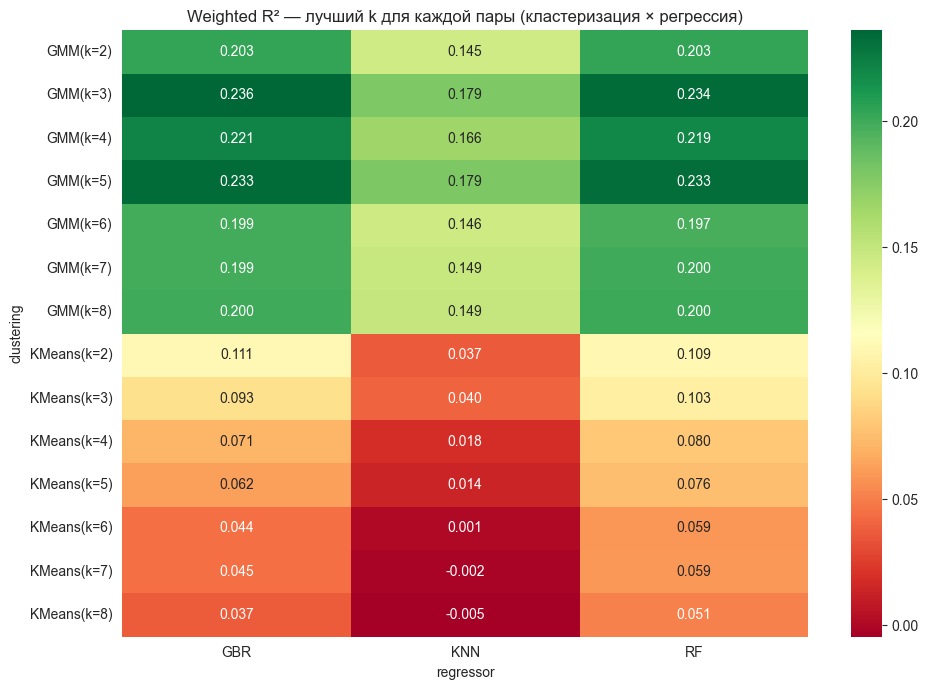

In [5]:
# Heatmap: clustering vs regressor (лучший k)
pivot = res_df.groupby(['clustering','regressor'])['weighted_r2'].max().unstack()
fig, ax = plt.subplots(figsize=(10, max(6, len(pivot)*0.5)))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax)
ax.set_title('Weighted R² — лучший k для каждой пары (кластеризация × регрессия)')
plt.tight_layout()
plt.show()

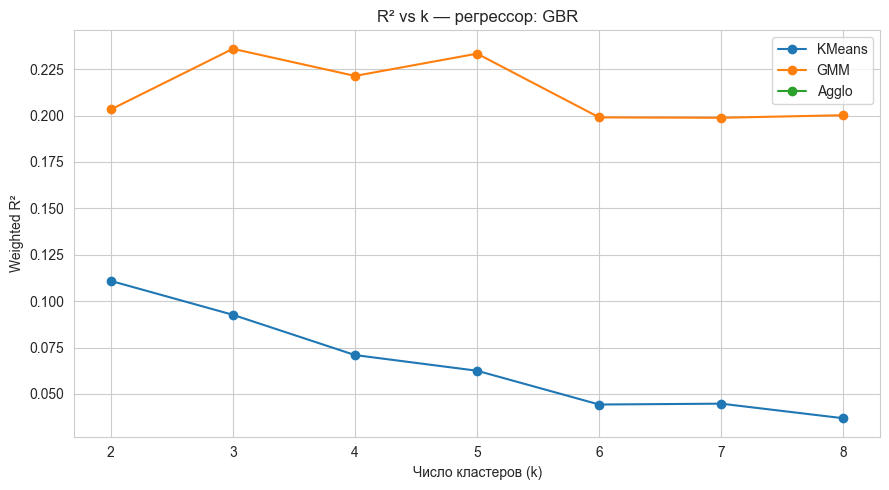

In [6]:
# R² vs k для топ-регрессора
best_reg = res_df.iloc[0]['regressor']
sub = res_df[res_df['regressor'] == best_reg]

fig, ax = plt.subplots(figsize=(9, 5))
for cl_base in ['KMeans', 'GMM', 'Agglo']:
    mask = sub['clustering'].str.startswith(cl_base)
    d = sub[mask].sort_values('k')
    ax.plot(d['k'], d['weighted_r2'], 'o-', label=cl_base)
ax.set_xlabel('Число кластеров (k)')
ax.set_ylabel('Weighted R²')
ax.set_title(f'R² vs k — регрессор: {best_reg}')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Финальная модель — обучение на полном датасете

In [7]:
# Берём лучшую комбинацию
best = res_df.iloc[0]
BEST_K = int(best['k'])
BEST_CL = best['clustering']
BEST_REG = best['regressor']
print(f'Лучшая комбинация: {BEST_CL} + {BEST_REG}, R²={best["weighted_r2"]:.4f}')

# Определяем финальный кластеризатор
if 'KMeans' in BEST_CL:
    final_cl = KMeans(BEST_K, n_init=10, random_state=42)
elif 'GMM' in BEST_CL:
    final_cl = GaussianMixture(BEST_K, random_state=42)
else:
    final_cl = AgglomerativeClustering(BEST_K)

# Кластеризация на полных данных
if hasattr(final_cl, 'predict'):
    final_cl.fit(X_clust)
    data['cluster'] = final_cl.predict(X_clust)
else:
    data['cluster'] = final_cl.fit_predict(X_clust)

print('\nРазмеры кластеров:')
print(data['cluster'].value_counts().sort_index())

Лучшая комбинация: GMM(k=3) + GBR, R²=0.2360

Размеры кластеров:
cluster
0     91868
1     37355
2    285826
Name: count, dtype: int64


In [9]:
# Обучаем регрессор внутри каждого кластера
from sklearn.model_selection import cross_val_score

def make_regressor(name):
    m = {
        'LinearReg': MultiOutputRegressor(LinearRegression()),
        'Ridge': MultiOutputRegressor(Ridge()),
        'KNN': KNeighborsRegressor(n_neighbors=10),
        'RF': MultiOutputRegressor(RandomForestRegressor(200, max_depth=12, random_state=42, n_jobs=-1)),
        'GBR': MultiOutputRegressor(GradientBoostingRegressor(n_estimators=200, max_depth=5, random_state=42)),
    }
    return m[name]

cluster_models = {}
cluster_scores = {}

for lbl in sorted(data['cluster'].unique()):
    mask = data['cluster'] == lbl
    Xc = data.loc[mask, FEATURES].values
    Yc = data.loc[mask, TARGETS].values
    
    model = make_regressor(BEST_REG)
    scores = cross_val_score(model, Xc, Yc, cv=5, scoring='r2')
    
    model.fit(Xc, Yc)
    cluster_models[lbl] = model
    cluster_scores[lbl] = {'r2_mean': scores.mean(), 'r2_std': scores.std(), 'n': mask.sum()}
    print(f'Кластер {lbl}: n={mask.sum():>6d}, R²={scores.mean():.4f} ± {scores.std():.4f}')

weighted_r2 = sum(v['r2_mean']*v['n'] for v in cluster_scores.values()) / len(data)
print(f'\nОбщий взвешенный R²: {weighted_r2:.4f}')

Кластер 0: n= 91868, R²=-0.0245 ± 0.1240
Кластер 1: n= 37355, R²=-1.7731 ± 1.8283
Кластер 2: n=285826, R²=0.1725 ± 0.1163

Общий взвешенный R²: -0.0462


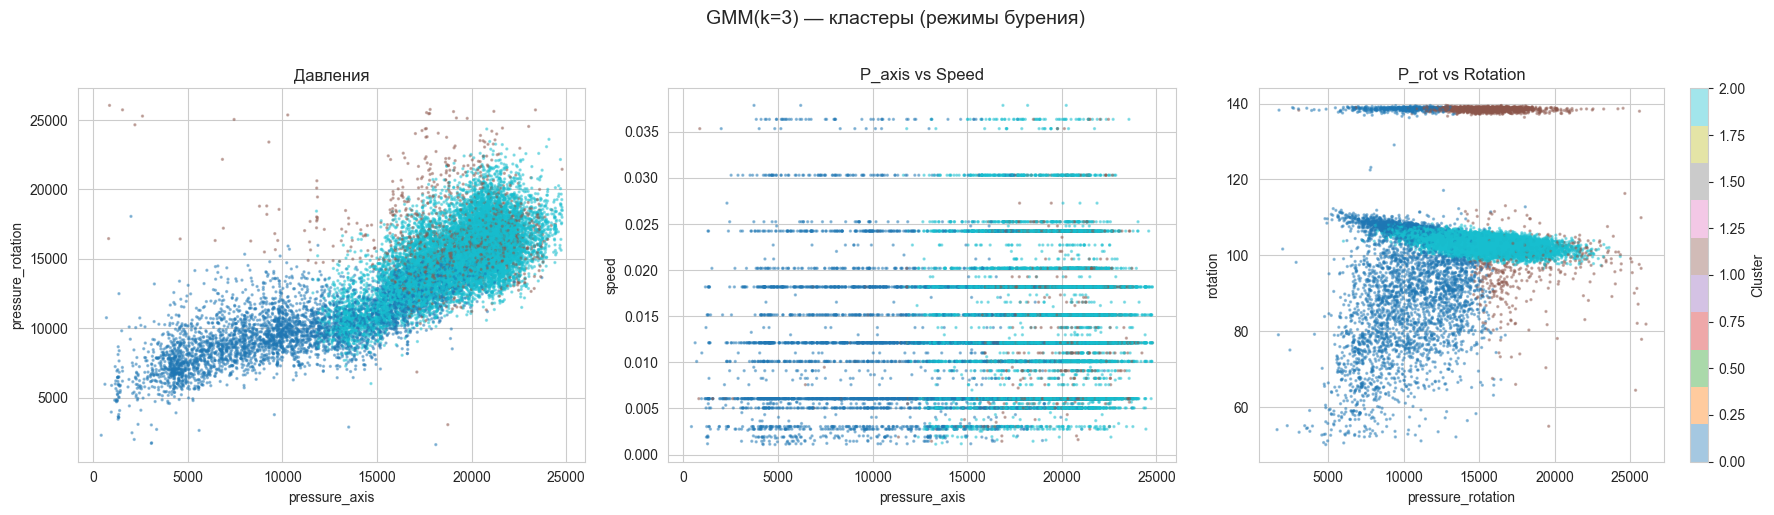

In [10]:
# Визуализация кластеров
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sample_idx = np.random.choice(len(data), min(20000, len(data)), replace=False)
ds = data.iloc[sample_idx]

for ax, (x, y, title) in zip(axes, [
    ('pressure_axis', 'pressure_rotation', 'Давления'),
    ('pressure_axis', 'speed', 'P_axis vs Speed'),
    ('pressure_rotation', 'rotation', 'P_rot vs Rotation'),
]):
    scatter = ax.scatter(ds[x], ds[y], c=ds['cluster'], cmap='tab10', s=2, alpha=0.4)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title)

plt.colorbar(scatter, ax=axes[-1], label='Cluster')
plt.suptitle(f'{BEST_CL} — кластеры (режимы бурения)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

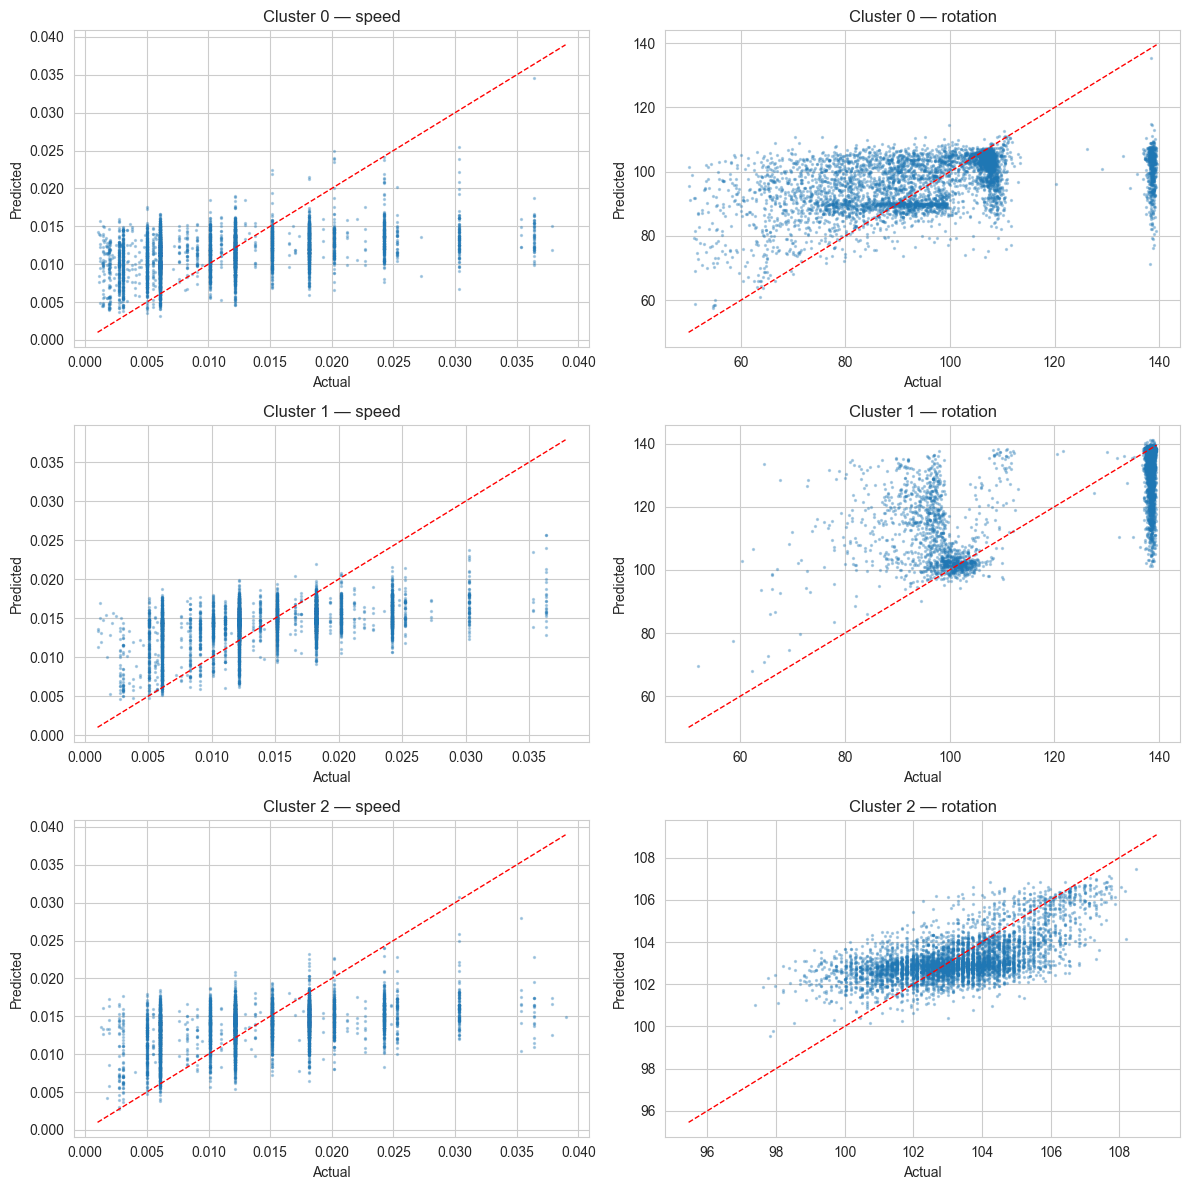

In [11]:
# Predicted vs Actual для каждого кластера
fig, axes = plt.subplots(BEST_K, 2, figsize=(12, 4*BEST_K))
if BEST_K == 1:
    axes = axes.reshape(1, -1)

for i, lbl in enumerate(sorted(cluster_models.keys())):
    mask = data['cluster'] == lbl
    Xc = data.loc[mask, FEATURES].values
    Yc = data.loc[mask, TARGETS].values
    Yp = cluster_models[lbl].predict(Xc)
    
    for j, tgt in enumerate(TARGETS):
        ax = axes[i, j]
        sub_idx = np.random.choice(len(Yc), min(5000, len(Yc)), replace=False)
        ax.scatter(Yc[sub_idx, j], Yp[sub_idx, j], s=2, alpha=0.3)
        mn, mx = Yc[:, j].min(), Yc[:, j].max()
        ax.plot([mn, mx], [mn, mx], 'r--', lw=1)
        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')
        ax.set_title(f'Cluster {lbl} — {tgt}')

plt.tight_layout()
plt.show()

## 5. Статистика по кластерам (режимы бурения)

In [12]:
summary = data.groupby('cluster')[ALL_COLS].agg(['mean','std','min','max'])
summary

pressure_axis                         pressure_rotation            \
                 mean       std    min    max              mean       std   
cluster                                                                     
0          11055.0386 4879.5159    390  24779        10044.2435 2332.4919   
1          19466.4638 2555.4299    317  24797        16339.0126 2518.9558   
2          19276.2523 2515.7257  10546  24872        15160.5344 2373.5445   

                      speed                      rotation                  \
          min    max   mean    std    min    max     mean     std     min   
cluster                                                                     
0         784  18311 0.0114 0.0072 0.0010 0.0390  96.8146 19.4039 50.0100   
1        1208  26318 0.0141 0.0062 0.0010 0.0379 127.4433 18.8742 50.0940   
2        1587  25390 0.0136 0.0063 0.0010 0.0390 103.1662  1.7044 95.4540   

                  
             max  
cluster           
0       139.5180  
1       139.5780  
2       109.0860

In [13]:
# Сводка
print('='*60)
print('ИТОГОВАЯ КОНФИГУРАЦИЯ')
print('='*60)
print(f'Кластеризация:  {BEST_CL}')
print(f'Регрессор:      {BEST_REG}')
print(f'Число кластеров: {BEST_K}')
print(f'Взвешенный R²:  {weighted_r2:.4f}')
print('='*60)
for lbl, sc in sorted(cluster_scores.items()):
    print(f'  Кластер {lbl}: n={sc["n"]:>6d}  R²={sc["r2_mean"]:.4f} ± {sc["r2_std"]:.4f}')

ИТОГОВАЯ КОНФИГУРАЦИЯ
Кластеризация:  GMM(k=3)
Регрессор:      GBR
Число кластеров: 3
Взвешенный R²:  -0.0462
  Кластер 0: n= 91868  R²=-0.0245 ± 0.1240
  Кластер 1: n= 37355  R²=-1.7731 ± 1.8283
  Кластер 2: n=285826  R²=0.1725 ± 0.1163
